In [1]:
import re, time, math, random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
CLASSES = ["World", "Sports", "Business", "Sci/Tech"]

def load(path):
    df = pd.read_csv(path)
    df["text"] = df["Title"] + " " + df["Description"]
    df["label"] = df["Class Index"] - 1
    return df[["text", "label"]]

full_train, test_df = load("/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/train.csv"), load("/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/test.csv")
train_df, val_df = train_test_split(full_train, test_size=0.1, stratify=full_train["label"], random_state=SEED)
train_df, val_df = train_df.reset_index(drop=True), val_df.reset_index(drop=True)
print(len(train_df), len(val_df), len(test_df))
train_df.head(3)

108000 12000 7600


,text,label
0,10 seconds that change everything ATHENS - Ten...,1
1,Charline Labonte rises to challenge Charline L...,1
2,Ex-El Paso Traders Plead Guilty to False Repor...,2


In [3]:
PAD, UNK, CLS = 0, 1, 2
MAX_LEN, MAX_VOCAB, MIN_FREQ = 64, 30000, 2

def tokenize(text):
    return re.findall(r"[a-z]+|\d+|[^\sa-z\d]", text.lower())

counter = Counter(t for text in train_df["text"] for t in tokenize(text))
itos = ["<pad>", "<unk>", "<cls>"] + [w for w, c in counter.most_common(MAX_VOCAB) if c >= MIN_FREQ]
stoi = {w: i for i, w in enumerate(itos)}
print("размер словаря:", len(itos))

def encode(text, max_len=MAX_LEN):
    ids = [CLS] + [stoi.get(t, UNK) for t in tokenize(text)][: max_len - 1]
    return ids + [PAD] * (max_len - len(ids))

def to_tensors(df):
    return torch.tensor([encode(t) for t in df["text"]]), torch.tensor(df["label"].values)

X_train, y_train = to_tensors(train_df)
X_val, y_val = to_tensors(val_df)
X_test, y_test = to_tensors(test_df)

BATCH = 256
train_dl = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH, shuffle=True)
val_dl = DataLoader(TensorDataset(X_val, y_val), batch_size=512)
test_dl = DataLoader(TensorDataset(X_test, y_test), batch_size=512)

lens = (X_train != PAD).sum(1).float()
print("средняя длина:", lens.mean().item(), "| доля обрезанных:", (lens == MAX_LEN).float().mean().item())

размер словаря: 30003
средняя длина: 46.36919403076172 | доля обрезанных: 0.1020648181438446


### Embeddings и positional encoding

Эмбеддинг — таблица `размер словаря × d_model`: каждому id соответствует вектор длины `d_model`.
Positional encoding — синусоидальный вектор той же длины, который прибавляется к эмбеддингу позиции `pos`:
`PE[pos, 2i] = sin(pos / 10000^(2i/d_model))`, `PE[pos, 2i+1] = cos(...)`.

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2], pe[:, 1::2] = torch.sin(pos * div), torch.cos(pos * div)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[: x.size(1)]

D_MODEL = 128
emb = nn.Embedding(len(itos), D_MODEL, padding_idx=PAD)
pos_enc = PositionalEncoding(D_MODEL)

ids = X_train[:4]
pad_mask = ids == PAD
e = emb(ids)
x = pos_enc(e)
print("ids       :", tuple(ids.shape))
print("pad_mask  :", tuple(pad_mask.shape), pad_mask.dtype)
print("embedding :", tuple(e.shape))
print("+ pos enc :", tuple(x.shape))
print("pe        :", tuple(pos_enc.pe.shape))

ids       : (4, 64)
pad_mask  : (4, 64) torch.bool
embedding : (4, 64, 128)
+ pos enc : (4, 64, 128)
pe        : (512, 128)


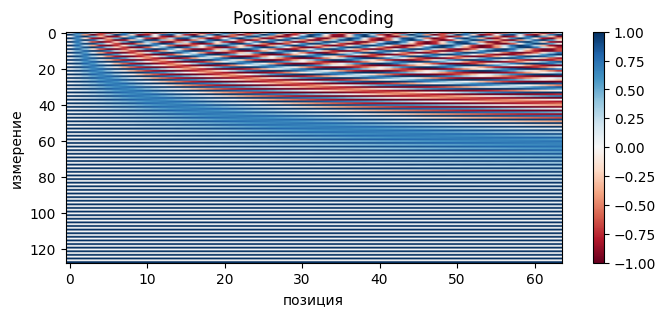

In [5]:
plt.figure(figsize=(8, 3))
plt.imshow(pos_enc.pe[:MAX_LEN].T, aspect="auto", cmap="RdBu")
plt.xlabel("позиция"); plt.ylabel("измерение"); plt.colorbar()
plt.title("Positional encoding")
plt.show()

Знакомый график "часовых и секундных стрелок". Все правильно работает

## Attention руками

(Деление на `√d` не даёт оценкам расти вместе с размерностью, иначе softmax насыщается и градиенты почти обнуляются)
(Padding: позиции перед softmax получают `-inf`, тогда их вес `exp(-inf) = 0`, а веса остальных позиций по-прежнему суммируются в единицу)

In [6]:
def scaled_dot_product_attention(q, k, v, pad_mask=None):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.size(-1))
    if pad_mask is not None:
        scores = scores.masked_fill(pad_mask[:, None, :], float("-inf"))
    weights = scores.softmax(dim=-1)
    return weights @ v, weights

In [7]:
toy_texts = ["stocks fall", "oil prices rise sharply today", "nba finals tonight"]
toy_ids = torch.tensor([encode(t, max_len=6) for t in toy_texts])
toy_mask = toy_ids == PAD
D_TOY = 8

torch.manual_seed(0)
toy_emb = nn.Embedding(len(itos), D_TOY, padding_idx=PAD)
toy_pe = PositionalEncoding(D_TOY)
Wq, Wk, Wv = (nn.Linear(D_TOY, D_TOY, bias=False) for _ in range(3))

xt = toy_pe(toy_emb(toy_ids))
Q, K, V = Wq(xt), Wk(xt), Wv(xt)
out, w = scaled_dot_product_attention(Q, K, V, toy_mask)
print("x:", tuple(xt.shape), "Q/K/V:", tuple(Q.shape), "out:", tuple(out.shape), "weights:", tuple(w.shape))

print("сумма весов по строкам == 1:", torch.allclose(w.sum(-1), torch.ones_like(w.sum(-1))))
print("вес на padding == 0        :", bool((w.masked_select(toy_mask[:, None, :].expand_as(w)) == 0).all()))

ref = F.scaled_dot_product_attention(Q, K, V, attn_mask=~toy_mask[:, None, :])
print("совпадает с F.scaled_dot_product_attention:", torch.allclose(out, ref, atol=1e-6))

print("\nвеса для 'stocks fall' (строка = query, столбец = key):")
print(w[0].detach().numpy().round(3))

x: (3, 6, 8) Q/K/V: (3, 6, 8) out: (3, 6, 8) weights: (3, 6, 6)
сумма весов по строкам == 1: True
вес на padding == 0        : True
совпадает с F.scaled_dot_product_attention: True

веса для 'stocks fall' (строка = query, столбец = key):
[[0.213 0.384 0.403 0.    0.    0.   ]
 [0.313 0.419 0.268 0.    0.    0.   ]
 [0.373 0.367 0.26  0.    0.    0.   ]
 [0.267 0.349 0.384 0.    0.    0.   ]
 [0.302 0.307 0.391 0.    0.    0.   ]
 [0.348 0.309 0.343 0.    0.    0.   ]]


In [8]:
scores_nomask = Q @ K.transpose(-2, -1) / math.sqrt(D_TOY)
w_nomask = scores_nomask.softmax(-1)
print("без маски вес на padding у 'stocks fall':", w_nomask[0, 0, toy_mask[0]].sum().item())
print("с маской                                :", w[0, 0, toy_mask[0]].sum().item())

без маски вес на padding у 'stocks fall': 0.4492006003856659
с маской                                : 0.0


## Модели

In [9]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, dim_ff=256, dropout=0.1, n_classes=4):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.pos = PositionalEncoding(d_model)
        layer = nn.TransformerEncoderLayer(d_model, nhead, dim_ff, dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers, norm=nn.LayerNorm(d_model), enable_nested_tensor=False)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(d_model, n_classes)
        self.scale = math.sqrt(d_model)

    def forward(self, ids):
        mask = ids == PAD
        x = self.drop(self.pos(self.emb(ids) * self.scale))
        h = self.encoder(x, src_key_padding_mask=mask)
        return self.head(h[:, 0])


class MeanBaseline(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_classes=4):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.head = nn.Sequential(nn.Dropout(0.1), nn.Linear(d_model, n_classes))

    def forward(self, ids):
        keep = (ids != PAD).unsqueeze(-1).float()
        pooled = (self.emb(ids) * keep).sum(1) / keep.sum(1)
        return self.head(pooled)


def n_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

batch = X_train[:4].to(device)
for m in (TransformerClassifier(len(itos)), MeanBaseline(len(itos))):
    m = m.to(device)
    print(type(m).__name__, tuple(m(batch).shape), n_params(m))

TransformerClassifier (4, 4) 4106116
MeanBaseline (4, 4) 3840900


In [10]:
@torch.no_grad()
def evaluate(model, dl):
    model.eval()
    loss_sum, logits_all = 0.0, []
    for xb, yb in dl:
        logits = model(xb.to(device))
        loss_sum += F.cross_entropy(logits, yb.to(device), reduction="sum").item()
        logits_all.append(logits.cpu())
    logits = torch.cat(logits_all)
    y = dl.dataset.tensors[1]
    return loss_sum / len(y), (logits.argmax(1) == y).float().mean().item(), logits


def fit(model, epochs, lr):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=epochs * len(train_dl), pct_start=0.1)
    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc, best_state, elapsed = 0.0, None, 0.0
    for ep in range(epochs):
        t0 = time.time()
        model.train()
        loss_sum, correct = 0.0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
            loss_sum += loss.item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
        elapsed += time.time() - t0
        vl, va, _ = evaluate(model, val_dl)
        hist["train_loss"].append(loss_sum / len(y_train)); hist["train_acc"].append(correct / len(y_train))
        hist["val_loss"].append(vl); hist["val_acc"].append(va)
        if va > best_acc:
            best_acc, best_state = va, {k: v.detach().clone() for k, v in model.state_dict().items()}
        print(f"epoch {ep+1:2d} | train loss {hist['train_loss'][-1]:.4f} acc {hist['train_acc'][-1]:.4f} "
              f"| val loss {vl:.4f} acc {va:.4f} | {time.time()-t0:.1f}s")
    model.load_state_dict(best_state)
    return hist, best_acc, elapsed

### Baseline: эмбеддинги + masked mean pooling

In [11]:
torch.manual_seed(SEED)
base = MeanBaseline(len(itos))
base_hist, base_best, base_time = fit(base, epochs=8, lr=3e-3)

epoch  1 | train loss 0.8921 acc 0.6494 | val loss 0.3305 acc 0.8993 | 2.4s
epoch  2 | train loss 0.2779 acc 0.9116 | val loss 0.2626 acc 0.9168 | 2.0s
epoch  3 | train loss 0.2123 acc 0.9310 | val loss 0.2515 acc 0.9202 | 2.3s
epoch  4 | train loss 0.1790 acc 0.9418 | val loss 0.2483 acc 0.9202 | 2.1s
epoch  5 | train loss 0.1582 acc 0.9483 | val loss 0.2504 acc 0.9194 | 2.1s
epoch  6 | train loss 0.1441 acc 0.9535 | val loss 0.2522 acc 0.9193 | 2.0s
epoch  7 | train loss 0.1355 acc 0.9559 | val loss 0.2532 acc 0.9189 | 2.0s
epoch  8 | train loss 0.1327 acc 0.9574 | val loss 0.2533 acc 0.9191 | 2.1s


### Transformer Encoder (токен `<cls>` + классификационная голова)

In [12]:
torch.manual_seed(SEED)
tr = TransformerClassifier(len(itos))
tr_hist, tr_best, tr_time = fit(tr, epochs=8, lr=5e-4)

epoch  1 | train loss 1.1070 acc 0.4991 | val loss 0.5228 acc 0.8127 | 10.7s
epoch  2 | train loss 0.4640 acc 0.8341 | val loss 0.3670 acc 0.8769 | 10.7s
epoch  3 | train loss 0.3638 acc 0.8734 | val loss 0.3197 acc 0.8929 | 10.8s
epoch  4 | train loss 0.3223 acc 0.8885 | val loss 0.3035 acc 0.8980 | 10.9s
epoch  5 | train loss 0.2969 acc 0.8973 | val loss 0.2977 acc 0.9007 | 11.1s
epoch  6 | train loss 0.2789 acc 0.9036 | val loss 0.2937 acc 0.9025 | 11.2s
epoch  7 | train loss 0.2715 acc 0.9070 | val loss 0.2927 acc 0.9034 | 11.3s
epoch  8 | train loss 0.2680 acc 0.9077 | val loss 0.2927 acc 0.9043 | 11.4s


## Анализ

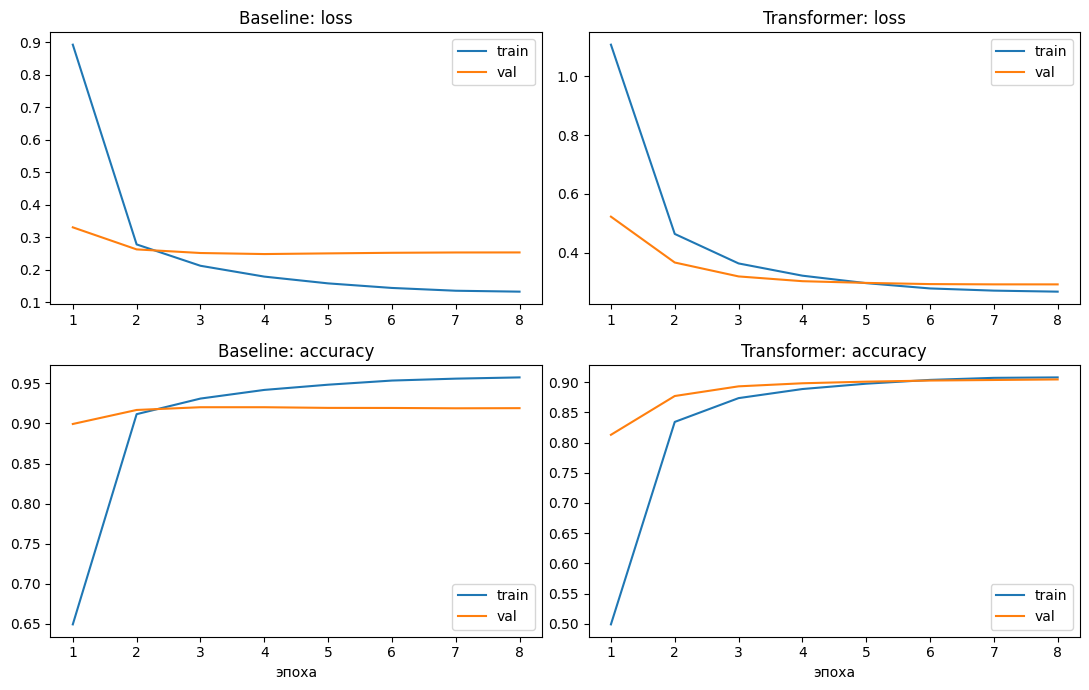

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
for j, (name, h) in enumerate([("Baseline", base_hist), ("Transformer", tr_hist)]):
    ep = range(1, len(h["val_loss"]) + 1)
    ax[0, j].plot(ep, h["train_loss"], label="train"); ax[0, j].plot(ep, h["val_loss"], label="val")
    ax[0, j].set_title(f"{name}: loss"); ax[0, j].legend()
    ax[1, j].plot(ep, h["train_acc"], label="train"); ax[1, j].plot(ep, h["val_acc"], label="val")
    ax[1, j].set_title(f"{name}: accuracy"); ax[1, j].legend(); ax[1, j].set_xlabel("эпоха")
plt.tight_layout(); plt.show()

Наш бейзлайн переобучается очень быстро.

### Проверка padding mask на обученной модели

In [14]:
tr.eval()
n = 5
ids = X_val[:n].to(device)
real_len = (ids != PAD).sum(1)

with torch.no_grad():
    full = tr(ids)
    trimmed = torch.stack([tr(ids[i:i+1, :real_len[i]])[0] for i in range(n)])
    x = tr.pos(tr.emb(ids) * tr.scale)
    no_mask = tr.head(tr.encoder(x)[:, 0])

print("длины:", real_len.tolist())
print("max |logits(с padding и маской) - logits(без padding)|:", (full - trimmed).abs().max().item())
print("max |logits(с padding, без маски) - logits(без padding)|:", (no_mask - trimmed).abs().max().item())

длины: [60, 56, 33, 37, 23]
max |logits(с padding и маской) - logits(без padding)|: 9.5367431640625e-07
max |logits(с padding, без маски) - logits(без padding)|: 1.7122957706451416


### Test: одна оценка выбранных checkpoint'ов

In [15]:
_, base_val_acc, _ = evaluate(base, val_dl)
_, tr_val_acc, _ = evaluate(tr, val_dl)

base_tl, base_ta, base_logits = evaluate(base, test_dl)
tr_tl, tr_ta, tr_logits = evaluate(tr, test_dl)

results = pd.DataFrame({
    "модель": ["Mean baseline", "Transformer Encoder"],
    "параметры": [n_params(base), n_params(tr)],
    "время обучения, с": [round(base_time, 1), round(tr_time, 1)],
    "val acc": [base_val_acc, tr_val_acc],
    "test loss": [base_tl, tr_tl],
    "test acc": [base_ta, tr_ta],
}).round(4)
results

,модель,параметры,"время обучения, с",val acc,test loss,test acc
0,Mean baseline,3840900,16.1,0.9202,0.2615,0.9137
1,Transformer Encoder,4106116,85.2,0.9043,0.2928,0.9062


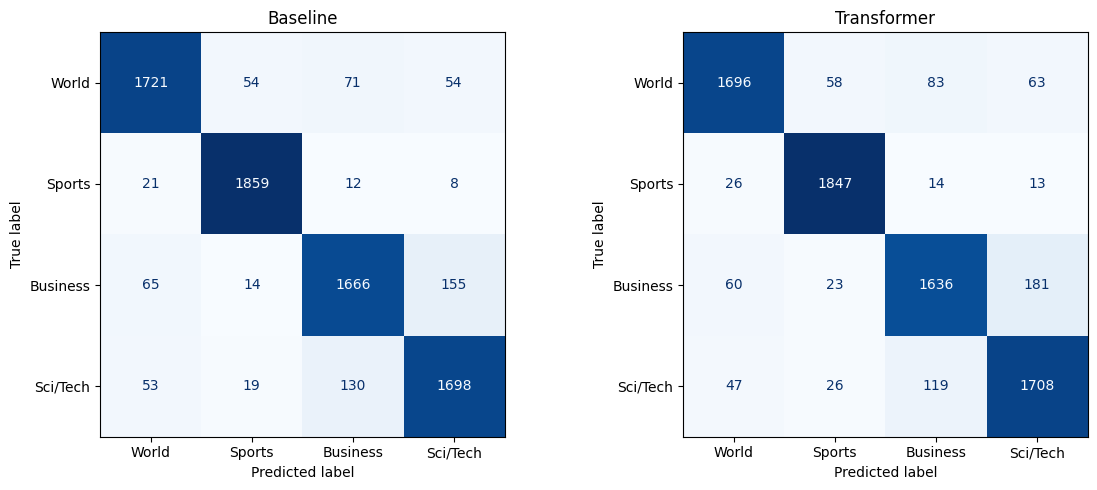

              precision    recall  f1-score   support

       World     0.9273    0.8926    0.9096      1900
      Sports     0.9452    0.9721    0.9585      1900
    Business     0.8834    0.8611    0.8721      1900
    Sci/Tech     0.8692    0.8989    0.8838      1900

    accuracy                         0.9062      7600
   macro avg     0.9063    0.9062    0.9060      7600
weighted avg     0.9063    0.9062    0.9060      7600



In [16]:
tr_pred = tr_logits.argmax(1).numpy()
y_np = y_test.numpy()
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, (name, lg) in zip(ax, [("Baseline", base_logits), ("Transformer", tr_logits)]):
    ConfusionMatrixDisplay.from_predictions(y_np, lg.argmax(1).numpy(), display_labels=CLASSES, ax=a, colorbar=False, cmap="Blues")
    a.set_title(name)
plt.tight_layout(); plt.show()
print(classification_report(y_np, tr_pred, target_names=CLASSES, digits=4))

Очень много ошибок в категории Business, причем что FP, что FN. Логично. Часто любая тема немного про бизнес, особенно технологии.

### Ошибочно классифицированные тексты (Transformer, самые уверенные ошибки)

In [17]:
probs = tr_logits.softmax(1)
conf, pred = probs.max(1)
wrong = (pred.numpy() != y_np).nonzero()[0]
top = wrong[conf[wrong].argsort(descending=True).numpy()][:8]

pd.set_option("display.max_colwidth", 220)
pd.DataFrame({
    "текст": test_df["text"].iloc[top].values,
    "истина": [CLASSES[i] for i in y_np[top]],
    "предсказано": [CLASSES[i] for i in pred[top]],
    "уверенность": conf[top].numpy().round(3),
})

,текст,истина,предсказано,уверенность
0,"Philippines mourns dead in Russian school siege The Philippines Saturday expressed quot;deepest sympathy quot; to the families of the dead in the Russian school siege on Friday, in which 322 people were killed when R...",Sci/Tech,World,1.000
1,Iran shuts reformist websites WEBSITES CLOSE to Iran #39;s leading reformist party have been blocked by religious hardliners in the police bureau of public morals.,Sci/Tech,World,0.999
2,"Israel to close Erez industrial zone before March Israel would start liquidating the Erez industrial zone in the northern Gaza Strip before launching the first stage of the disengagement plan in March 2005,local news...",Business,World,0.999
3,"At Last, Success on the Road for Lions The Detroit Lions went three full seasons without winning an away game, setting an NFL record for road futility. They ended that ignominious streak Sunday in their first opportu...",World,Sports,0.997
4,Indonesian diplomats asked to help improve RI #39;s bad image JAKARTA (Antara): President Susilo Yudhoyono asked Indonesian diplomats on Monday to help the government improve Indonesia #39;s bad image.,Business,World,0.997
5,Before-the-Bell: GenCorp Falls 5.6 Pct. (Reuters) Reuters - Shares of GenCorp Inc. fell 5.6\percent before the opening bell on Monday after investment fund\Steel Partners withdrew its proposal to acquire the aerospa...,Sci/Tech,Business,0.997
6,"Sources: Sprint, Nextel closing in on \$36B deal Sprint Corp. is in advanced talks to buy Nextel Communications Inc. for more than \$36 billion in a mostly stock deal, sources familiar with the situation said today.",Sci/Tech,Business,0.997
7,"Embattled Mortgage Giant Agrees to Meet New Standards Fannie Mae agreed to keep more cash on hand while it corrects accounting problems, a U.S. regulator said.",World,Business,0.997


Лейблы за гранью добра и зла. Кто это размечал..?

### Attention weights

`nn.TransformerEncoderLayer` не возвращает веса, поэтому вызываем `self_attn` первого слоя напрямую на том же входе, который слой подаёт в attention (при `norm_first=True` это `norm1(x)`).
Берём одну head из четырёх; для следующих слоёв вход зависел бы от выходов предыдущих, поэтому показан только первый слой.

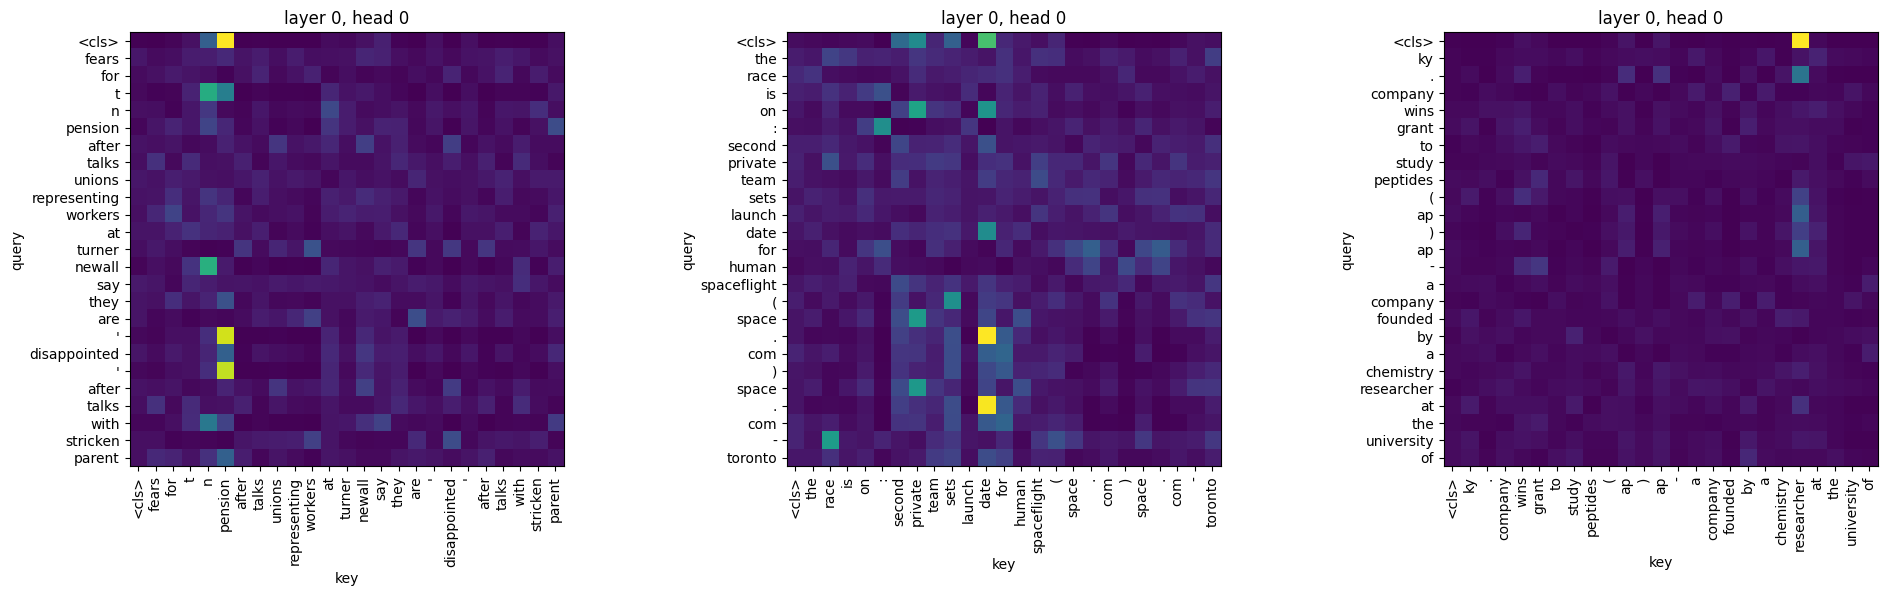

строки весов суммируются в 1: True


In [18]:
@torch.no_grad()
def first_layer_attention(model, text):
    model.eval()
    ids = torch.tensor([encode(text)]).to(device)
    mask = ids == PAD
    x = model.pos(model.emb(ids) * model.scale)
    layer = model.encoder.layers[0]
    h = layer.norm1(x)
    _, w = layer.self_attn(h, h, h, key_padding_mask=mask, need_weights=True, average_attn_weights=False)
    n = int((~mask).sum())
    tokens = ["<cls>"] + tokenize(text)[: n - 1]
    return tokens, w[0, :, :n, :n].cpu()

HEAD = 0
samples = [test_df["text"].iloc[i] for i in (0, 1, 2)]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for a, text in zip(axes, samples):
    tokens, w = first_layer_attention(tr, text)
    tokens, w = tokens[:25], w[HEAD, :25, :25]
    a.imshow(w, cmap="viridis")
    a.set_xticks(range(len(tokens)), tokens, rotation=90); a.set_yticks(range(len(tokens)), tokens)
    a.set_xlabel("key"); a.set_ylabel("query"); a.set_title(f"layer 0, head {HEAD}")
plt.tight_layout(); plt.show()

tokens, w = first_layer_attention(tr, samples[0])
print("строки весов суммируются в 1:", torch.allclose(w.sum(-1), torch.ones_like(w.sum(-1)), atol=1e-5))

## Движение тензора через модель (credit за визуализацию, естественно, Клоду)

```
ids                      (B, L)            B=256, L=64; id из словаря, <cls> на позиции 0, справа <pad>
  │ pad_mask = (ids == PAD)  (B, L)        True там, где padding
  ▼
nn.Embedding             (B, L, D)         D=128; строка таблицы на каждый id
  │ × √D
  ▼
+ positional encoding    (B, L, D)         прибавляется PE[pos], форма не меняется
  │ dropout
  ▼
┌─ TransformerEncoderLayer × 2 (pre-norm) ─────────────────────────────┐
│  h = LayerNorm(x)                          (B, L, D)                 │
│  Q, K, V = h·Wq, h·Wk, h·Wv → 4 головы    (B, 4, L, 32)             │
│  scores = Q·Kᵀ/√32, pad_mask → -inf        (B, 4, L, L)             │
│  weights = softmax(scores)                 (B, 4, L, L)             │
│  heads → concat → ·Wo                      (B, L, D)                │
│  x = x + attn_out                          residual                  │
│  x = x + FFN(LayerNorm(x))                 D→256→D, residual         │
└──────────────────────────────────────────────────────────────────────┘
  │ LayerNorm
  ▼
h[:, 0]  (вектор <cls>)  (B, D)
  │ Linear(D, 4)
  ▼
logits                   (B, 4)  → softmax → вероятности классов
```

## Роли компонентов

**Q, K, V.** Каждый токен порождает три вектора. Query токена *i* сравнивается скалярным произведением с Key каждого токена *j*; после softmax получаются веса, и выход токена *i* — сумма Value всех токенов с этими весами.
Пример: если веса токена `oil` равны (0.7 на `prices`, 0.3 на себя), его новый вектор = 0.7·V(`prices`) + 0.3·V(`oil`). Разделение на Q/K/V позволяет модели отдельно учить, *по чему искать* (Q, K) и *что передавать* (V).

**Positional encoding.** Attention не зависит от порядка: перестановка токенов переставляет строки результата, но ничего не меняет по существу, поэтому «dog bites man» и «man bites dog» неотличимы. Прибавление вектора позиции даёт одному и тому же слову разные входы в разных местах предложения.

**Residual connection.** Выход подслоя прибавляется к его входу: `x + Sublayer(x)`. Градиент при обратном проходе идёт по этому сложению напрямую, не проходя через attention или FFN, поэтому глубокие стеки обучаются, а слой при необходимости может выучить «ничего не менять».

**LayerNorm.** Для каждого токена отдельно вычитает среднее и делит на стандартное отклонение по `D` координатам вектора (затем обучаемые масштаб и сдвиг). Пример: вектор (1, 3, 5) → среднее 3, отклонение ≈1.63 → (−1.22, 0, 1.22). Это держит масштаб активаций постоянным от слоя к слою и стабилизирует обучение; в отличие от BatchNorm не зависит от размера батча и от padding-токенов в нём.

**Padding mask.** Без неё `<pad>` участвует в softmax и «размывает» веса настоящих токенов; результат модели тогда зависит от длины, до которой дополнен батч (проверено выше).